In [1]:
# autoreload
%load_ext autoreload
%autoreload 2

from scipy import signal
from scipy import interpolate
from scipy import ndimage
import numpy as np
import pycatch22 
from sktime.transformations.panel import catch22
import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
load_dotenv = dotenv.load_dotenv('../.env')
# load local library
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import extractor
import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

from time import sleep

from scipy.stats import skew, kurtosis
from scipy.fft import rfft, rfftfreq
from scipy.signal import cwt, ricker
import pymannkendall as mk

# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AffinityPropagation, SpectralClustering, HDBSCAN
from sklearn.mixture import GaussianMixture as GMM
from umap import UMAP
from scaler import GaussRankScaler
from sklearn.pipeline import Pipeline

import nolds

import datetime

from numba import jit


In [2]:
START_TIME = datetime.datetime.now()

In [3]:
AKI_PATH = os.environ['AKI_PATH']
os.chdir(AKI_PATH)

In [4]:
ts_data = pd.read_parquet("ts.parquet.snappy")

In [5]:
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

In [6]:
AKI_PATH

'L:\\\\lab_research\\\\RES-Folder-UPOD\\\\Nostradamus/E_ResearchData/2_ResearchData/Prd_RenalFunc'

In [7]:
# load pre-selection
preselection = pd.read_parquet("./Bram/test_result.parquet")

PRESELECT_PATIENTS = preselection.ID.unique()
PRESELECT_PATIENT_CLASSES = preselection[['ID', 'class']+[f'prob{i}' for i in range(1,11)]]\
                                .drop_duplicates(subset=['ID', 'class'])
                                
ts_data = ts_data[ts_data.ID.isin(PRESELECT_PATIENTS)]

## Exploration

In [8]:
min_days_length = 1*365
maxts = ts_data.groupby('ID').Time_days.max()
ltids = maxts[maxts>min_days_length].index

print(f'There are {ltids.shape[0]} patients (or {round(100*ltids.shape[0]/maxts.shape[0], 2)}%) with minimally {min_days_length} days of measurements')

There are 215 patients (or 100.0%) with minimally 365 days of measurements


## Preprocess

In [9]:
RangeList = [1825, 3650] #+ list(np.arange(1*365,10*365, 365))
WINDOW_SIZE = 3 # for smoothing
MIN_MEASUREMENTS_PER_YEAR = 2
SMOOTHING_TYPE = None #'gaussian_kernel' # rolling_mean or gaussian_kernel
STANDARDIZE_TS = False
STANDARDIZE_TYPE = 'minmax'
TIME_RESOLUTION = 14 # days, for interpolation.

RangeDFDictRaw = {}
RangeDFDict = {}
RangeDFDict_smoothed = {}
for MinDays in RangeList:
    MIN_MEASUREMENTS = np.floor(MIN_MEASUREMENTS_PER_YEAR*MinDays/365)
    
    print(f'Filtering for min days: {MinDays}')
    ts_temp = preprocessing.get_filtered_df(ts_data.copy(), 
                                            id_col='ID', 
                                            time_col='Time_days',
                                            min_days=MinDays, 
                                            min_measurements=MIN_MEASUREMENTS)
    
    RangeDFDictRaw[MinDays] = ts_temp
     
    if STANDARDIZE_TS:
        print(f'Standardizing for min days: {MinDays}')
        ts_temp = preprocessing.normalise_ts(ts_temp, 
                                             id_col='ID', 
                                             time_col='Time_days',
                                             val_col='eGFR_CKDEpi2012',
                                             df_out=True,
                                             scaler=STANDARDIZE_TYPE)
    
    
    print(f'Interpolating for min days: {MinDays}')
    RangeDFDict[MinDays] = preprocessing.get_interpolated(ts_temp, id_col='ID', time_col='Time_days',
                                              max_days=MinDays,
                                              val_col='eGFR_CKDEpi2012',
                                              time_res=TIME_RESOLUTION,
                                              df_out=True)
    
    print(f"Smoothing for min days: {MinDays} with window {WINDOW_SIZE}")
    if SMOOTHING_TYPE == 'rolling_mean':
        RangeDFDict_smoothed[MinDays] = preprocessing.get_smoothed_rolling_mean(RangeDFDict[MinDays],
                                                        id_col='ID', time_col='Time_days',
                                                        val_col='eGFR_CKDEpi2012', 
                                                        window=WINDOW_SIZE, 
                                                        df_out=True)
    elif SMOOTHING_TYPE == 'gaussian_kernel':
        RangeDFDict_smoothed[MinDays] = preprocessing.get_smoothed_gaussian_kernel(RangeDFDict[MinDays],
                                                        id_col='ID', time_col='Time_days',
                                                        val_col='eGFR_CKDEpi2012', 
                                                        window=WINDOW_SIZE,
                                                        df_out=True)
    

Filtering for min days: 1825
Interpolating for min days: 1825


100%|██████████| 214/214 [00:00<00:00, 719.46it/s]


Smoothing for min days: 1825 with window 3


100%|██████████| 214/214 [00:00<00:00, 913.09it/s]


Filtering for min days: 3650
Interpolating for min days: 3650


100%|██████████| 214/214 [00:00<00:00, 757.99it/s]


Smoothing for min days: 3650 with window 3


100%|██████████| 214/214 [00:00<00:00, 720.24it/s]


In [10]:
CrossSectDict = {}
# get_smoothNsmooth_diffStatistics
for MinDays in RangeList:
    print(f'Getting cross-sectional features for min days, for the smoothed set, with periods of: {MinDays} days')
    tsS = RangeDFDict_smoothed[MinDays]
    smoothed_cross = extractor.get_crossectional(tsS, 
                                        id_col='ID',
                                        val_col='eGFR_CKDEpi2012',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'Getting cross-sectional features for min days, for the raw set, with periods of: {MinDays} days')
    tsR = RangeDFDict[MinDays]
    raw_cross = extractor.get_crossectional(tsR, 
                                        id_col='ID',
                                        val_col='eGFR_CKDEpi2012',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'Merging cross-sectional features for min days, the raw set, with periods of: {MinDays} days')
    merged_cross = smoothed_cross.merge(raw_cross,
                                        left_index=True, 
                                        right_index=True, 
                                        suffixes=('_smoothed', '_raw'))
    smoothNsmoothStats = extractor.get_smoothNsmooth_diffStatistics(tsS,tsR, 
                                                                    id_col='ID',
                                                                    val_col='eGFR_CKDEpi2012',
                                                                    time_col='Time_days')
    
    smoothed_cross = smoothed_cross.merge(smoothNsmoothStats, left_index=True, right_index=True)
    raw_cross = raw_cross.merge(smoothNsmoothStats, left_index=True, right_index=True)
    merged_cross = merged_cross.merge(smoothNsmoothStats, left_index=True, right_index=True)

    CrossSectDict[MinDays] = {
                              'smoothed': smoothed_cross,
                              'raw': raw_cross,
                              'merged': merged_cross
                            }
    
    gc.collect()

Getting cross-sectional features for min days, for the smoothed set, with periods of: 1825 days


 36%|███▌      | 76/214 [00:08<00:10, 13.23it/s]\\ds\data\LAB\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
\\ds\data\LAB\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 214/214 [00:00<00:00, 606.15it/s]


Getting cross-sectional features for min days, for the raw set, with periods of: 1825 days


 97%|█████████▋| 208/214 [00:17<00:00, 11.37it/s]\\ds\data\LAB\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
\\ds\data\LAB\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 214/214 [00:00<00:00, 468.28it/s]


Merging cross-sectional features for min days, the raw set, with periods of: 1825 days
Getting cross-sectional features for min days, for the smoothed set, with periods of: 3650 days


100%|██████████| 214/214 [00:00<00:00, 265.21it/s]


Getting cross-sectional features for min days, for the raw set, with periods of: 3650 days


 72%|███████▏  | 155/214 [00:31<00:12,  4.59it/s]\\ds\data\LAB\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
\\ds\data\LAB\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 214/214 [00:00<00:00, 277.18it/s]


Merging cross-sectional features for min days, the raw set, with periods of: 3650 days


## Remove redundant features

In [11]:
# remove features that have more than N% of missing values
MAX_MISSING_VALUES_PER_COLUMN = 0.5

print("Removing features for all periods that are too sparse")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        missing_ratio = FINAL_FEATURES.isna().sum(axis=0)/\
                            FINAL_FEATURES.shape[0]
        missing_cols = missing_ratio[missing_ratio>MAX_MISSING_VALUES_PER_COLUMN].index
        
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=missing_cols)
        num_rem.append(missing_cols.shape[0])
        
print(f"Number of columns removed: {num_rem}")

Removing features for all periods that are too sparse


100%|██████████| 2/2 [00:00<?, ?it/s]

Number of columns removed: [0, 0, 0, 0, 0, 0]


In [12]:
# remove plus or minus infinity values
print("Removing infinite values")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        inf_cols = FINAL_FEATURES.columns[FINAL_FEATURES.isin([np.inf, -np.inf]).any()]
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=inf_cols)
        num_rem.append(inf_cols.shape[0])

Removing infinite values


100%|██████████| 2/2 [00:00<00:00, 67.33it/s]


In [13]:
from sklearn.feature_selection import VarianceThreshold

print("Removing zero variance features for all periods...")
num_zero = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        var_thresh = VarianceThreshold(threshold=0.)
        var_thresh.fit(FINAL_FEATURES)
        variances = var_thresh.variances_

        # remove features with zero variance
        zero_variance_features = FINAL_FEATURES.columns[variances == 0]
        non_zero_variance_features = FINAL_FEATURES.columns[variances > 0]
        FINAL_FEATURES = FINAL_FEATURES.drop(zero_variance_features, axis=1)
        
        CrossSectDict[period][key] = FINAL_FEATURES
        num_zero.append(zero_variance_features.shape[0])  
        
print(f"Number of columns removed: {num_zero}")

Removing zero variance features for all periods...


100%|██████████| 2/2 [00:00<00:00, 46.17it/s]

Number of columns removed: [1, 0, 1, 1, 0, 1]


In [14]:
# remove features that are highly correlated
print("Removing perfectly correlated features for all periods...")
num_corr = []
duplicated = set()
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        #dist_matrix = 1-FINAL_FEATURES.corr(method='spearman').abs()
        #cols = dist_matrix.columns        
        cols = FINAL_FEATURES.columns
        droplist = []
        for i,cl in enumerate(cols):
            for cr in cols[i+1:]:
                if FINAL_FEATURES[cl].equals(FINAL_FEATURES[cr]):
                    droplist.append(cr)
                    duplicated.add((cl, cr))
        to_drop = list(set(droplist))
                
        FINAL_FEATURES = FINAL_FEATURES.drop(columns=to_drop)
        CrossSectDict[period][key] = FINAL_FEATURES
        num_corr.append(len(to_drop))
print(f"Number of columns removed: {num_corr}")

Removing perfectly correlated features for all periods...


100%|██████████| 2/2 [00:00<00:00,  5.02it/s]

Number of columns removed: [0, 0, 0, 0, 0, 0]


In [15]:
print(f"Duplicate column-pairs: {duplicated}")


Duplicate column-pairs: set()


## Imputation

In [16]:
pipe_kwargs = {}

In [17]:
#imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer
pipe_kwargs['imputer'] = {'default': {'n_neighbors' :7, 'weights': 'distance'}
                          }

## Scale

In [18]:
#scaler = GaussRankScaler()
#scaler = QuantileTransformer(output_distribution='normal')
scaler = StandardScaler
pipe_kwargs['scaler'] = {'default': {}
                         }


## Reducer

In [19]:
reducer = PCA
#reducer = UMAP(n_components=6, n_neighbors=15, min_dist=0., metric='manhattan')
pipe_kwargs['reducer'] = {'default': {'n_components' : 50},
                          'variable': {'n_components': lambda dim: min(dim, 50)}
                          }

## Cluster

In [20]:
#clusterer = HDBSCAN(min_cluster_size=20, min_samples=15, cluster_selection_epsilon=0.5)
#clusterer = KMeans(n_clusters=3)
clusterer = GMM
pipe_kwargs['clusterer'] = {'default': {'n_components': 10},
                            'variable': {'n_components': [3,6,10,24,32]}
                            }

# Run pipeline

In [21]:
ModelDict = {}
ClustDict = defaultdict(lambda: defaultdict(dict))
for period in tqdm(CrossSectDict.keys()):
    ModelDict[period] = {}
    for preptype in CrossSectDict[period].keys():
        df = CrossSectDict[period][preptype].copy()
        # TODO: this is stupid, improve perhaps?
        if pipe_kwargs['reducer'].get('variable'):
            pipe_kwargs['reducer']['default']['n_components'] = pipe_kwargs['reducer']['variable']['n_components'](df.shape[1])

        if pipe_kwargs['clusterer'].get('variable'):
            # assumes variation of number of components
            if isinstance(pipe_kwargs['clusterer']['variable']['n_components'], list):
                for n_comp in pipe_kwargs['clusterer']['variable']['n_components']:
                    pipe_kwargs['clusterer']['default']['n_components'] = n_comp
                    
                    le_pipe_de_prep = Pipeline([
                                ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                                ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                                ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
                    
                    le_pipe_clusterer = Pipeline([
                                ('prepper', le_pipe_de_prep),
                                ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                                verbose=False)   
                    
                    le_pipe_clusterer.fit(df.values)
                    
                    ModelDict[period][preptype] = {}
                    ModelDict[period][preptype][n_comp] = le_pipe_clusterer
                    
                    clust_clf = le_pipe_clusterer.named_steps['clusterer']
                    
                    if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = clust_clf.labels_
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = clust_clf.probabilities_
                    else:
                        prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = le_pipe_clusterer.predict(df.values)
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)
                        CrossSectDict[period][preptype][f'AIC_{n_comp}'] = clust_clf.aic(prepped_df)
                        CrossSectDict[period][preptype][f'BIC_{n_comp}'] = clust_clf.bic(prepped_df)                   
            else:
                raise ValueError("We expect a list for n_components :)")                
        else:
            le_pipe_de_prep = Pipeline([
                        ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                        ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                        ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
            
            le_pipe_clusterer = Pipeline([
                        ('prepper', le_pipe_de_prep),
                        ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                        verbose=False)  
            le_pipe_clusterer.fit(df.values)
            
            clust_clf = le_pipe_clusterer.named_steps['clusterer']
            if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                CrossSectDict[period][preptype]['cluster'] = clust_clf.labels_
                CrossSectDict[period][preptype]['cluster_proba'] = clust_clf.probabilities_
            else:
                prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                CrossSectDict[period][preptype]['cluster'] = le_pipe_clusterer.predict(df.values)
                CrossSectDict[period][preptype]['cluster_proba'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)               
                CrossSectDict[period][preptype]['AIC'] = clust_clf.aic(prepped_df)
                CrossSectDict[period][preptype]['BIC'] = clust_clf.bic(prepped_df)   
            ModelDict[period][preptype] = le_pipe_clusterer
            
        AIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'AIC' in c]      
        BIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'BIC' in c]       
        if len(AIC_cols)>0:     
            ClustDict[period][preptype]['AIC'] = {aic_col.split("_")[1]: CrossSectDict[period][preptype][aic_col].mean() for aic_col in AIC_cols}
            ClustDict[period][preptype]['BIC'] = {bic_col.split("_")[1]: CrossSectDict[period][preptype][bic_col].mean() for bic_col in BIC_cols}
            
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if ('cluster_' in c) & ('_proba' not in c)]      
        cluster_proba_cols = [c for c in CrossSectDict[period][preptype].columns 
                                    if 'cluster_proba' in c]
        
        if len(cluster_cols)>0:
            ClustDict[period][preptype]['clusters']= CrossSectDict[period][preptype][cluster_cols]
        if len(cluster_proba_cols)>0:
            ClustDict[period][preptype]['cluster_probas']= CrossSectDict[period][preptype][cluster_proba_cols]

100%|██████████| 2/2 [00:02<00:00,  1.13s/it]


In [22]:
END_TIME = datetime.datetime.now()
DURATION = (END_TIME-START_TIME)

print(f"The runs took about {END_TIME-START_TIME} h/s")

The runs took about 0:02:24.594284 h/s


## Plot

In [23]:
aic_list = []
bic_list = []
for period in tqdm(ClustDict.keys()):
    for preptype in ClustDict[period].keys():
        tDict = ClustDict[period][preptype]['AIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        aic_list.append(tDict)
        
        tDict = ClustDict[period][preptype]['BIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        bic_list.append(tDict)
        
aic_df = pd.DataFrame(aic_list).set_index(['period', 'preptype']).T
aic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in aic_df.columns.values]

bic_df = pd.DataFrame(bic_list).set_index(['period', 'preptype']).T
bic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in bic_df.columns.values]

min_aic_ind = [{c: aic_df.index[aic_df[c].argmin()]} for c in aic_df.columns]
min_bic_ind = [{c: bic_df.index[bic_df[c].argmin()]} for c in bic_df.columns]

100%|██████████| 2/2 [00:00<?, ?it/s]


In [24]:
aic_df

,1825_smoothed,1825_raw,1825_merged,3650_smoothed,3650_raw,3650_merged
3,9586.356975,11856.753610,27053.774353,5957.282168,12827.335748,27598.988052
6,-10589.662603,-2369.135180,3651.108382,-7110.527108,-5511.733976,-1271.210591
10,-24470.757440,-27093.172791,-13016.793258,-29721.297838,-17670.145092,-13512.002606
24,-21702.205532,-17931.231180,-22921.955976,-25899.872370,-19400.081074,-23497.376022
32,-12081.506968,-13021.506208,-11447.316894,-12076.134873,-13480.245316,-8225.768797


In [25]:
bic_df

,1825_smoothed,1825_raw,1825_merged,3650_smoothed,3650_raw,3650_merged
3,22972.843586,25243.240222,40440.260965,19343.768780,26213.822360,40985.474664
6,16186.676597,24407.204019,30427.447582,19665.812092,21264.605223,25505.128608
10,20158.718543,17536.303192,31612.682725,14908.178145,26959.330891,31117.473378
24,85413.249194,89184.223546,84193.498750,81215.582356,87715.373652,83618.078704
32,130740.221326,129800.222085,131374.411400,130745.593420,129341.482978,134595.959497


In [26]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDictRaw[period] = \
            pd.merge(RangeDFDictRaw[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 2/2 [00:00<00:00, 11.63it/s]


In [27]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDict_smoothed[period] = \
            pd.merge(RangeDFDict_smoothed[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 2/2 [00:00<00:00, 11.86it/s]


In [28]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        #RangeDFDict[period] = pd.DataFrame(RangeDFDict[period])
        RangeDFDict[period] = \
            pd.merge(RangeDFDict[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 2/2 [00:00<00:00, 14.30it/s]


In [29]:
RangeDFDict_smoothed[3650].cluster_24_merged.value_counts()

cluster_24_merged
1     5220
11    5220
22    5220
12    4437
13    3915
3     3654
16    3132
8     2871
23    2610
6     2610
9     2349
4     2349
7     2088
2     1827
14    1827
20    1305
15    1305
17    1044
18     783
5      783
10     522
19     261
0      261
21     261
Name: count, dtype: int64

<Axes: xlabel='Time_days', ylabel='eGFR_CKDEpi2012'>

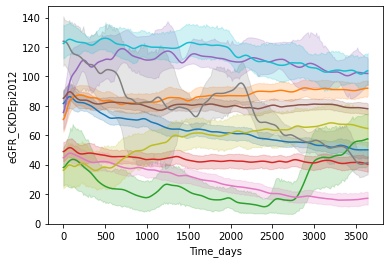

In [30]:
#sns.color_palette("tab10")
sns.lineplot(data=RangeDFDict_smoothed[3650], 
             x='Time_days',
             y='eGFR_CKDEpi2012',
             hue='cluster_10_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             )

c:\Users\bes3\VIRTUALENVS\base\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


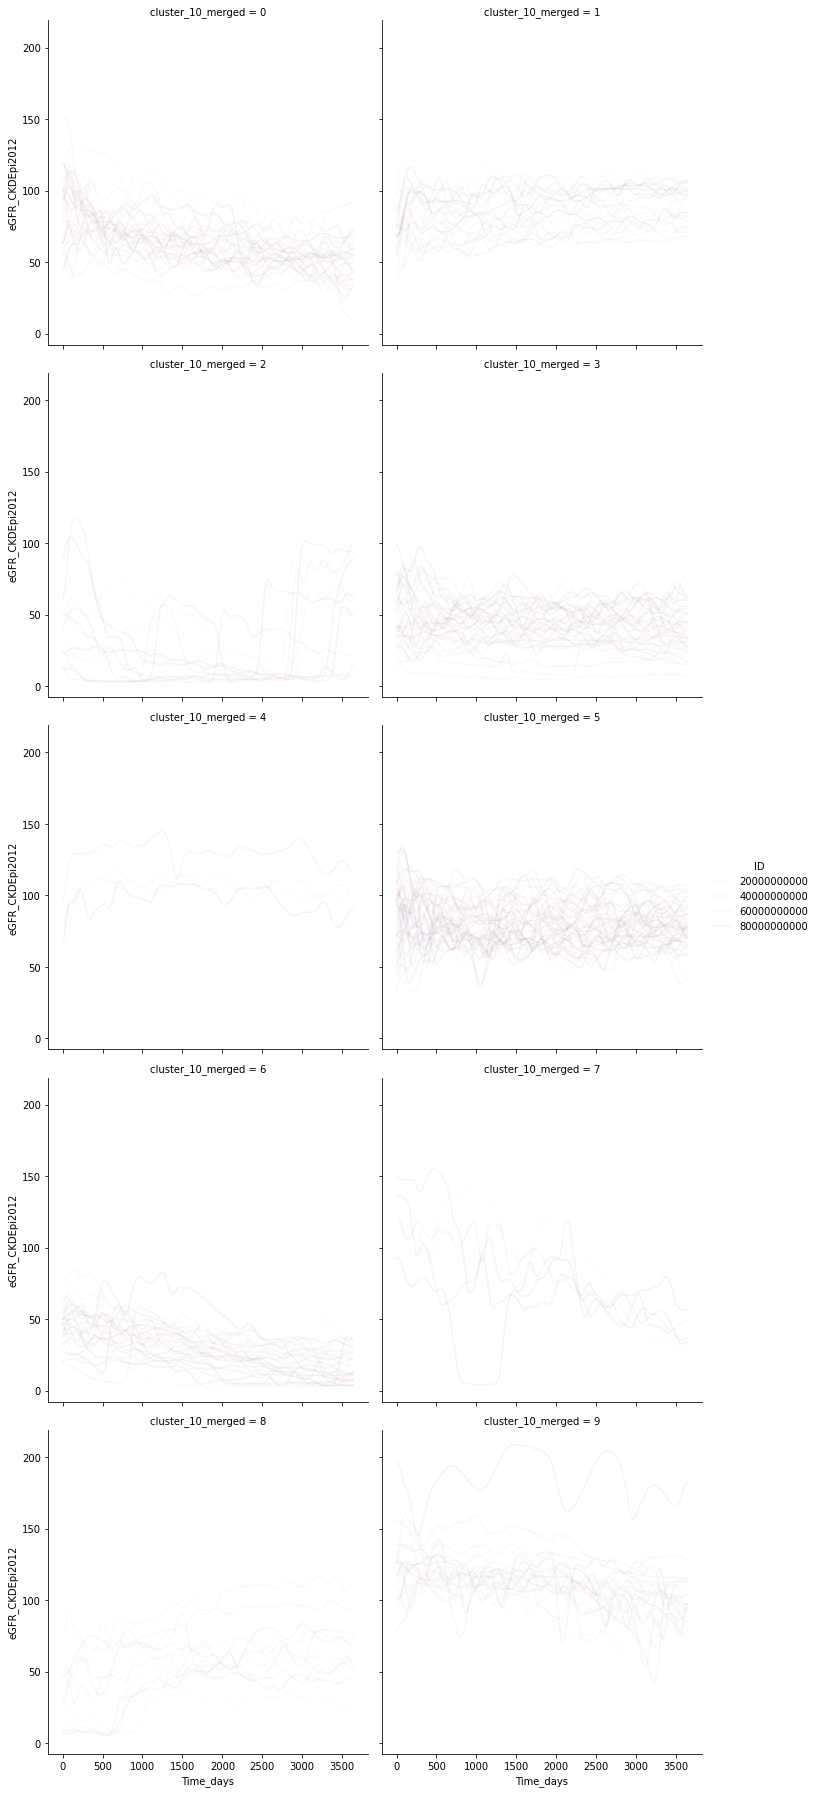

In [31]:
sns.relplot(data=RangeDFDict_smoothed[3650], 
             x='Time_days',
             y='eGFR_CKDEpi2012',
             hue='ID',
             kind='line',
             col='cluster_10_merged',
             col_wrap=2,
             alpha=0.05,
             color='black'
             )

## Compare our results with the reference results

* Jaccard
* Mutual information..

In [32]:
OurResult = RangeDFDict_smoothed[3650][['ID', 'cluster_10', 'cluster_10_raw', 'cluster_10_merged']]\
                                .drop_duplicates()
OurResult.set_index('ID', inplace=True)
#
LCCMResult = PRESELECT_PATIENT_CLASSES[['ID', 'class']]
LCCMResult.set_index('ID', inplace=True)
#
RandomResult = OurResult.copy()
RandomResult['cluster_10'] = np.random.randint(0,10, size=OurResult.shape[0])
RandomResult['cluster_10_raw'] = np.random.randint(0,10, size=OurResult.shape[0])
RandomResult['cluster_10_merged'] = np.random.randint(0,10, size=OurResult.shape[0])

In [33]:
from sklearn.metrics import adjusted_mutual_info_score as ami, adjusted_rand_score as ari
from sklearn.metrics import normalized_mutual_info_score as nmi

In [34]:
RandomResult.columns = [f'random_{c}' for c in RandomResult.columns]
OurResult.columns = [f'timex_{c}' for c in OurResult.columns]
LCCMResult.columns = [f'lcmm_{c}' for c in LCCMResult.columns]
LCCMResult.index  = LCCMResult.index.astype('int64')

In [35]:
MergedResults = OurResult.join(RandomResult, how='inner').join(LCCMResult,  how='inner')

<Axes: >

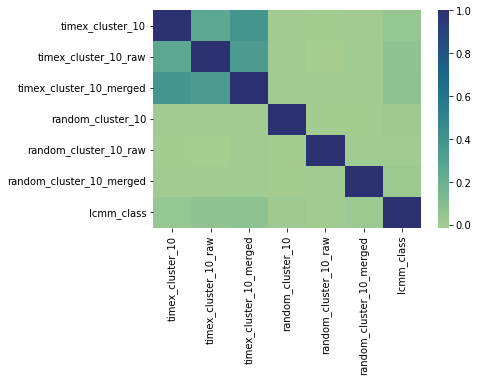

In [36]:
sns.heatmap(MergedResults.corr(method=ari), cmap="crest")

<Axes: >

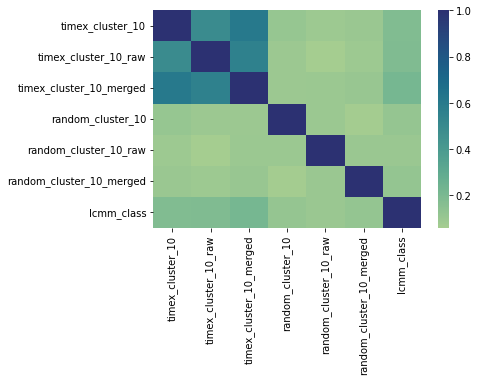

In [37]:
sns.heatmap(MergedResults.corr(method=nmi), cmap="crest")

In [38]:
MergedResults.corr(method=nmi)

,timex_cluster_10,timex_cluster_10_raw,timex_cluster_10_merged,random_cluster_10,random_cluster_10_raw,random_cluster_10_merged,lcmm_class
timex_cluster_10,1.000000,0.491137,0.605830,0.109298,0.085741,0.099177,0.178873
timex_cluster_10_raw,0.491137,1.000000,0.554506,0.090048,0.059957,0.087629,0.183852
timex_cluster_10_merged,0.605830,0.554506,1.000000,0.091770,0.093523,0.104096,0.217460
random_cluster_10,0.109298,0.090048,0.091770,1.000000,0.094339,0.066258,0.114257
random_cluster_10_raw,0.085741,0.059957,0.093523,0.094339,1.000000,0.097072,0.098610
random_cluster_10_merged,0.099177,0.087629,0.104096,0.066258,0.097072,1.000000,0.115333
lcmm_class,0.178873,0.183852,0.217460,0.114257,0.098610,0.115333,1.000000


In [39]:
preselection.ID = preselection.ID.astype('int64')

c:\Users\bes3\VIRTUALENVS\base\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


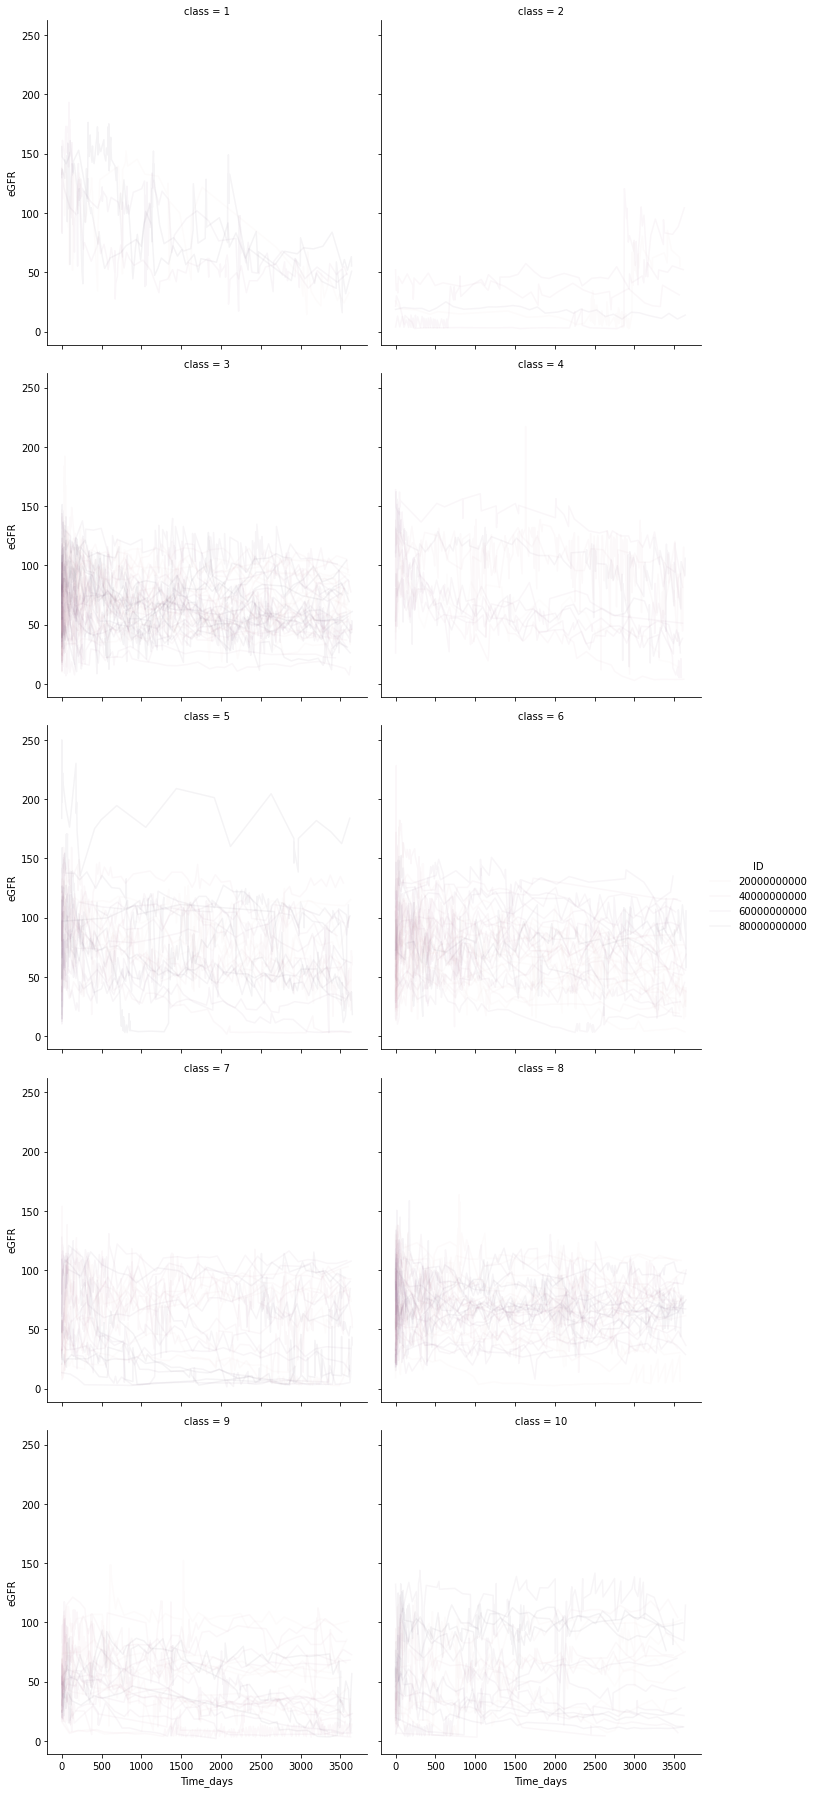

In [40]:
sns.relplot(data=preselection.query('Time_days<3650 and Class=="Observed"'), 
             x='Time_days',
             y='eGFR',
             hue='ID',
             kind='line',
             col='class',
             col_wrap=2,
             alpha=0.05,
             color='black'
             )